# Morphological tree clones: BayesForest structural data analysis (Potapov et al., 2017)

**Paper:** I. Potapov, M. Järvenpää, M. Åkerblom, P. Raumonen, M. Kaasalainen,
*"A generator of morphological clones for plant species"*, bioRxiv
[10.1101/108530](https://doi.org/10.1101/108530) (v1, 2017-02-14); journal version:
*Bayes Forest: a data-intensive generator of morphological tree clones*,
GigaScience 6(10), 2017.

**Author code:** BayesForest MATLAB toolbox, github.com/inuritdino/BayesForest,
pinned commit `3f6c81e9b135719b9a7e479dc5d2c07b392cd9de` (MIT license, see repo `COPYING`).
**Data:** Espoo maple QSM feature tables (`EspooBraData.txt`, `EspooSegData.txt`)
linked as direct files from the authors' [Data-samples wiki](https://github.com/inuritdino/BayesForest/wiki/Data-samples),
plus the `morpho-clones.zip` release archive from the TUT Bayes-Forest materials page.

## Scope and execution status — read first

This notebook is a **partial demonstration (authors' MATLAB code executed via Octave)** of
the paper's data-side pipeline on the actual Espoo maple QSM:

1. load the QSM tables and extract the paper's structural data sets S_w and B_w
   (segment/branch features per topological order, Table 1 of the paper);
2. render the input tree (side and top views);
3. compute the paper's **structural distance** DS (mean Kolmogorov–Smirnov statistic over
   1000 quasi-Monte-Carlo projection directions) using the **authors' own `dt_distance` code**;
4. compute the classical clone-evaluation metrics (height, girth, crown spread).

**NOT executed:** the stochastic growth model (SSM/SOT), the genetic-algorithm
optimization, and clone generation. The SOT model runs through the external **LPFG
simulator** (VLAB / L-studio; the authors used a 64-bit Mac OS X binary) under MATLAB
R2015b, with reported run times up to several days — neither is installable in Colab.
No clone-generation result is claimed or fabricated. The split-half distance values in
section 7 are a self-consistency check of the measurement framework — **they are not
published paper results**.

> **AI-assisted adaptation notice (EN):** The authors did not provide this Octave/Colab
> implementation. The author's MATLAB functions are executed with minimal,
> behavior-preserving edits (nested functions → subfunctions; classdef tree → struct
> shim; orientation-explicit cross product). Every edit is asserted and documented next
> to the code. Untested behavior is not guaranteed.
>
> **AI による翻訳・適用の注意 (JP):** 著者自身の MATLAB コードを最小限の書き換えで
> Octave により実行しています。クローン生成(SSM+LPFG+GA)は実行されていません。
> セクション 7 の距離値は論文の結果値ではありません。未検証の挙動は保証されません。

## Runtime: CPU only — select **Runtime → Change runtime type → CPU** (default is fine)

No GPU is used anywhere in this reproduction; all work is linear algebra on ~19,000 rows.
Expected wall time on the free Colab CPU runtime: **~5–10 minutes** total
(~2–5 min Octave installation, a few MB of downloads, seconds per analysis step).

**Run all:** `Runtime → Run all`. The notebook is self-contained: it installs Octave and
downloads the pinned author code and the data *inside* Colab; all outputs are written
under `/content`. Nothing runs on any external machine.

(日本語) GPU は不要です。CPU ランタイムで全体 5〜10 分程度です。
「ランタイム → すべてのセルを実行」で動作します。

## 1. Environment setup

**Purpose:** install GNU Octave (a free MATLAB-language interpreter) on the Colab VM.
Expected result: an Octave version banner is printed. The author's toolbox targets
MATLAB R2015b; on Colab we run the same `.m` language with Octave — the exact functions
executed are pinned and shown below.

(日本語) Colab に GNU Octave をインストールします。著者の MATLAB コードを同じ言語で
実行するためです。

In [ ]:
import shutil, subprocess

if shutil.which("octave") is None:
    # Streamed install so failures are visible; bounded by the outer timeout.
    subprocess.run(
        ["bash", "-lc",
         "apt-get update -qq && DEBIAN_FRONTEND=noninteractive apt-get install -y -qq octave"],
        check=True, timeout=900)
r = subprocess.run(["octave", "--version"], capture_output=True, text=True, timeout=60)
print(r.stdout.splitlines()[0])
assert "octave" in r.stdout.lower(), "Octave installation could not be verified"
print("octave ready")

GNU Octave, version 8.4.0
octave ready


## 2. Fetch the pinned author code (code files only)

**Purpose:** download the exact author `.m` functions used by this demonstration from the
pinned repository revision, with SHA-256 provenance. These are code files; all *dataset*
downloads happen in the next cell. Function roles (paper phase ↔ code):
- `qsm_data/gen_scatter2.m` — extracts the S_w/B_w structural data sets (paper
  "Structural data sets U" phase; feature definitions documented in its header).
- `qsm_data/import_qsm_data.m` — reads the QSM branch/segment tables.
- `qsm_data/helpers/*` — geometry helpers used by the above.
- `dt_distance/*` — the structural distance DS ("Distance measure" phase):
  `dt_distance.m` → `dt_gof_statistic.m` → `ks_statistic.m` + `emp_cdf.m`;
  `lin_1d_transforms.m` → `generate_NT_net.m` (quasi-MC projection directions).

(日本語) 著者リポジトリの指定コミットから必要な .m ファイルのみを取得し、SHA-256 を記録します。

In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "3f6c81e9b135719b9a7e479dc5d2c07b392cd9de"
BASE = f"https://raw.githubusercontent.com/inuritdino/BayesForest/{COMMIT}"
FILES = [
    "qsm_data/gen_scatter2.m",
    "qsm_data/import_qsm_data.m",
    "qsm_data/helpers/rotation_matrix.m",
    "qsm_data/helpers/distances_to_line.m",
    "qsm_data/helpers/mat_vec_subtraction.m",
    "dt_distance/dt_distance.m",
    "dt_distance/dt_gof_statistic.m",
    "dt_distance/ks_statistic.m",
    "dt_distance/emp_cdf.m",
    "dt_distance/lin_1d_transforms.m",
    "dt_distance/generate_NT_net.m",
]
BASE_DIR = pathlib.Path("/content/bf")
for rel in FILES:
    dest = BASE_DIR / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        with urllib.request.urlopen(f"{BASE}/{rel}", timeout=120) as resp:
            data = resp.read()
        assert data.lstrip().startswith(b"function"), f"unexpected content in {rel}"
        dest.write_bytes(data)
    h = hashlib.sha256(dest.read_bytes()).hexdigest()
    print(f"{rel:45s} {dest.stat().st_size:7d} B  sha256:{h[:16]}...")
print("pinned commit:", COMMIT)

qsm_data/gen_scatter2.m                         29132 B  sha256:45456bf2170f0df2...
qsm_data/import_qsm_data.m                       2349 B  sha256:a4d25e9804620a21...
qsm_data/helpers/rotation_matrix.m                467 B  sha256:4b162c05656930df...


qsm_data/helpers/distances_to_line.m              533 B  sha256:624768f239c6ba6c...
qsm_data/helpers/mat_vec_subtraction.m            239 B  sha256:962da38e02a88c35...
dt_distance/dt_distance.m                        4288 B  sha256:b6a1573d0b208140...


dt_distance/dt_gof_statistic.m                  13395 B  sha256:27e432612b698785...
dt_distance/ks_statistic.m                       1720 B  sha256:6d749634369ee6b6...


dt_distance/emp_cdf.m                            1376 B  sha256:16800cfe15aeb912...
dt_distance/lin_1d_transforms.m                  5476 B  sha256:9f5a3dc99706ffbd...


dt_distance/generate_NT_net.m                    3523 B  sha256:8f98b2512695e48a...
pinned commit: 3f6c81e9b135719b9a7e479dc5d2c07b392cd9de


## 3. Fetch the Espoo maple QSM data (dataset bytes — Colab only)

**Purpose:** download the paper's QSM feature tables for the Espoo maple, linked as
direct files from the authors' wiki *Data-samples* page, and verify them against the
paper's description (QSM ≈ 19,000 cylinders ≈ 3,078 branches). We also do a bounded
inspection of the paper's release archive `morpho-clones.zip` (TUT materials page):
only its file listing is read, to document what the release contains. Its SSM/LPFG
simulation parts are **not** used or executed.

(日本語) Espoo マープル QSM の特徴量テーブルをダウンロードし、行数・列数を検証します。
`morpho-clones.zip` は内容リストの確認のみ行います。

In [ ]:
import hashlib, pathlib, urllib.request, zipfile
import numpy as np

DATA = pathlib.Path("/content/data"); DATA.mkdir(exist_ok=True)
WIKI_RAW = "https://raw.githubusercontent.com/wiki/inuritdino/BayesForest/qsm/espoo"
TUT = "http://math.tut.fi/inversegroup/app/bayesforest/v1/qsm/espoo"

def fetch(name):
    for base in (WIKI_RAW, TUT):
        url = f"{base}/{name}"
        try:
            with urllib.request.urlopen(url, timeout=180) as resp:
                data = resp.read()
            if len(data) > 1000:
                print(f"{name}: {len(data)} bytes from {base}")
                return data
            print(f"{name}: too small a response at {url}")
        except Exception as e:
            print(f"{name}: failed at {url}: {e}")
    raise RuntimeError(f"Could not download {name} from any documented source")

for name in ("EspooBraData.txt", "EspooSegData.txt"):
    p = DATA / name
    if not p.exists():
        p.write_bytes(fetch(name))
    raw = p.read_bytes()
    print(name, len(raw), "bytes sha256:" + hashlib.sha256(raw).hexdigest()[:16] + "...")

Bra = np.loadtxt(DATA / "EspooBraData.txt")
Seg = np.loadtxt(DATA / "EspooSegData.txt")
print("EspooBraData:", Bra.shape, "(paper/wiki: 3,078 branches)")
print("EspooSegData:", Seg.shape, "(paper/wiki: 19,000 cylinders)")
assert Bra.shape[1] >= 5 and Seg.shape[1] >= 12, "unexpected table column count"
assert abs(Bra.shape[0] - 3078) <= 5 and abs(Seg.shape[0] - 19000) <= 5, "table sizes disagree with the paper's QSM description"

# Bounded inspection of the release archive: HEAD size gate, then listing only.
ZIP_URL = "http://math.tut.fi/inversegroup/app/bayesforest/v1/morpho-clones.zip"
zip_path = DATA / "morpho-clones.zip"
size = None
try:
    req = urllib.request.Request(ZIP_URL, method="HEAD")
    with urllib.request.urlopen(req, timeout=60) as resp:
        size = int(resp.headers.get("Content-Length", -1))
    print("morpho-clones.zip HEAD:", size, "bytes")
except Exception as e:
    print("HEAD failed:", e)
if size is not None and 0 < size < 300_000_000:
    if not zip_path.exists():
        with urllib.request.urlopen(ZIP_URL, timeout=600) as resp, open(zip_path, "wb") as f:
            while True:
                chunk = resp.read(1 << 20)
                if not chunk:
                    break
                f.write(chunk)
    print("downloaded", zip_path.stat().st_size, "bytes")
    names = zipfile.ZipFile(zip_path).namelist()
    exts = {}
    for n in names:
        ext = n.rsplit(".", 1)[-1].lower() if "." in n else "(noext)"
        exts[ext] = exts.get(ext, 0) + 1
    print("archive entries:", len(names), "by extension:", dict(sorted(exts.items())))
    print("has EspooData.mat:", any(n.endswith("EspooData.mat") for n in names))
    print(".mtg files (SSM tree outputs):", sum(n.endswith(".mtg") for n in names))
    print("top-level entries:", sorted({n.split("/")[0] for n in names})[:20])
else:
    print("archive skipped (missing or too large); continuing with the direct QSM tables.")

EspooBraData.txt: 155946 bytes from https://raw.githubusercontent.com/wiki/inuritdino/BayesForest/qsm/espoo
EspooBraData.txt 155946 bytes sha256:4d3d9a8db24ff818...


EspooSegData.txt: 1634246 bytes from https://raw.githubusercontent.com/wiki/inuritdino/BayesForest/qsm/espoo
EspooSegData.txt 1634246 bytes sha256:34a4d9b6f7db0f61...
EspooBraData: (3078, 8) (paper/wiki: 3,078 branches)
EspooSegData: (19000, 14) (paper/wiki: 19,000 cylinders)


morpho-clones.zip HEAD: 15879401 bytes


downloaded 15879401 bytes
archive entries: 327 by extension: {'(noext)': 2, '1/': 1, '13/': 2, '14/': 1, '15/': 1, '16/': 2, '17/': 2, '19/': 1, '2016_????/': 1, '21/': 1, '22/': 1, '23/': 1, '24/': 2, '25/': 1, '28/': 1, '32/': 1, '34/': 1, '36/': 2, '37/': 2, '38/': 1, '39/': 2, '4/': 1, '43/': 1, '44/': 1, '45/': 3, '46/': 1, '47/': 1, '5/': 1, '51/': 1, '52/': 1, '53/': 1, '54/': 1, '55/': 1, '9/': 1, 'dat': 45, 'ds_store': 1, 'fig': 37, 'm': 2, 'mat': 38, 'png': 111, 'py': 2, 'txt': 46, 'zip': 1}
has EspooData.mat: True
.mtg files (SSM tree outputs): 0
top-level entries: ['morpho-clones']


## 4. Octave compatibility adaptation (documented, behavior-preserving)

**Purpose:** make mechanical edits to the author code so it runs on Octave, changing no
numerical operation:

1. `gen_scatter2.m` uses MATLAB *nested functions* (`compute_az`, `compute_lapar`,
   `curvature`) that share the parent workspace — **Octave does not support nested
   functions**. They are moved to ordinary subfunctions with the shared variables passed
   explicitly; the formulas are untouched.
2. The original `cross()` calls rely on MATLAB's tolerance of mixed row/column vector
   orientation; `crossv()` makes the orientation explicit (row output) — the same 3-D
   cross product.
3. `tree()` is a MATLAB `classdef`; this code path only assigns fields to the object, so
   a plain-struct shim of the same name is used. The classdef file is *not* placed on
   the Octave path.

The transformation is applied to the freshly downloaded author file, and every expected
edit is asserted — the cell fails loudly if the pinned source does not match.

(日本語) Octave がサポートしない「ネストした関数」をサブ関数へ移動する等、挙動を変えない
機械的な修正のみを加え、assert で各置換を検証します。

In [ ]:
import pathlib, re

BF = pathlib.Path("/content/bf")
lines = (BF / "qsm_data" / "gen_scatter2.m").read_text().splitlines(True)

# 1) take the active region (the rest of the file is commented-out legacy code)
cut = next(i for i, l in enumerate(lines) if l.startswith("% for k = 1:MAX_W"))
active = "".join(lines[:cut])

# 2) extract the three nested functions
m_az = re.search(r"    function az = compute_az\(br\)(.*?)\n    end\n", active, re.S)
m_lp = re.search(r"    function lapar = compute_lapar\(br,order\)(.*?)\n    end\n", active, re.S)
m_cv = re.search(r"    function \[gamma, zeta\] = curvature\(next,prev\)(.*?)\n    end\n", active, re.S)
assert m_az and m_lp and m_cv, "nested function layout changed in pinned source"

inline_i = next(i for i, l in enumerate(lines[:cut]) if "INLINE FUNCTIONS" in l)
body = "".join(lines[:inline_i])

# 3) route the nested calls to explicit-argument subfunctions
subs = {
    "compute_az(Br(ii))": "compute_az(Br(ii), Axe, FCB, CPar, U, V, W)",
    "compute_lapar(Br(ii),order)": "compute_lapar(Br(ii),order, CPar, FCB, BOrd, CiB, Sta, Axe, Len)",
    "curvature(seg,k)": "curvature(seg,k, Axe, W)",
}
for old, new in subs.items():
    assert body.count(old) == 1, f"expected exactly one call site for {old}"
    body = body.replace(old, new)

# 4) orientation-independent cross product (5 call sites in the active region)
assert active.count("cross(") == 5 and "crossv(" not in active, "unexpected cross() usage"

def cvt(s):
    return re.sub(r"\bcross\(", "crossv(", s)

az_fn = m_az.group(0).replace("compute_az(br)", "compute_az(br, Axe, FCB, CPar, U, V, W)")
lp_fn = m_lp.group(0).replace("compute_lapar(br,order)", "compute_lapar(br,order, CPar, FCB, BOrd, CiB, Sta, Axe, Len)")
cv_fn = m_cv.group(0).replace("curvature(next,prev)", "curvature(next,prev, Axe, W)")

header = "\n".join([
    "% gen_scatter2_octave.m - Octave-compatible adaptation of",
    "% qsm_data/gen_scatter2.m, inuritdino/BayesForest @ 3f6c81e9b135719b9a7e479dc5d2c07b392cd9de",
    "% Behavior-preserving edits (documented in the notebook):",
    "%  1. MATLAB nested functions moved to subfunctions with explicit args;",
    "%  2. cross() -> crossv() (orientation-independent 3-D cross product);",
    "%  3. classdef tree object replaced by a plain-struct shim (tree.m).",
    "% All numerical operations are unchanged.",
]) + "\n"
CROSSV = "\n".join([
    "function c = crossv(a, b)",
    "% Adaptation helper: 3-D cross product independent of input orientation.",
    "% Row-vector result, matching how the result is consumed downstream.",
    "c = reshape(cross(a(:), b(:)), 1, 3);",
    "end",
    ""]) + "\n"
SHIM = "\n".join([
    "function tr = tree()",
    "% Octave compatibility shim for this notebook (documented adaptation).",
    "% Original: classdef tree in @tree/tree.m, inuritdino/BayesForest",
    "% commit 3f6c81e9b135719b9a7e479dc5d2c07b392cd9de (MIT).",
    "% On this notebook's code path only field assignments are used, so a plain",
    "% struct with the same field names replaces the class object.",
    "tr = struct();",
    "end",
    ""]) + "\n"
adapted = (header + cvt(body).replace("function [Branch, Segment, tree_out] = gen_scatter2(input_data_file)",
            "function [Branch, Segment, tree_out] = gen_scatter2_octave(input_data_file)")
           + "end\n\n" + cvt(az_fn) + "\n" + cvt(lp_fn) + "\n" + cvt(cv_fn) + "\n" + CROSSV)
(BF / "gen_scatter2_octave.m").write_text(adapted)
(BF / "tree.m").write_text(SHIM)
print("wrote /content/bf/gen_scatter2_octave.m (%d lines) and tree.m shim" % len(adapted.splitlines()))

wrote /content/bf/gen_scatter2_octave.m (361 lines) and tree.m shim


## 5. Run the author's pipeline on the Espoo QSM

**Purpose:** run the author's own `import_qsm_data` and the adapted `gen_scatter2` in
Octave on the downloaded tables. This produces the paper's structural data sets per
topological order w: **S_w** (segment features: radius, length, gamma, zeta curvature
angles) and **B_w** (branch features: branching angle, azimuth, total length, initial
radius, distance along the parent) — Table 1 of the paper. We use **S1** and **B2**, the
orders used in the paper's examples, and export them for the analysis cells.

Expected result: per-order sample counts consistent with a ~19,000-cylinder,
~3,078-branch QSM (most branches of order 1–4), plus exported `S1.csv` / `B2.csv`.

(日本語) 著者コードで QSM テーブルから次数 w ごとの構造データセット S_w/B_w を抽出し、
S1 と B2 を CSV に書き出します。

In [ ]:
import pathlib, subprocess

WORK = pathlib.Path("/content/work"); WORK.mkdir(exist_ok=True)
READER = r'''
function A = read_table(fn)
% whitespace-aware numeric table reader with bounded fallbacks
try
  A = importdata(fn);
catch
  try
    A = dlmread(fn);
  catch
    fid = fopen(fn);
    C = textscan(fid, '%f', 'CollectOutput', 1, 'MultipleDelimsAsOne', 1);
    fclose(fid);
    A = cell2mat(C);
  end
end
if columns(A) < 5
  error('read_table: unexpected column count');
end
end
'''
DRIVER = r'''
addpath(genpath('/content/bf'));
cd('/content/work');
Bra = read_table('/content/data/EspooBraData.txt');
Seg = read_table('/content/data/EspooSegData.txt');
printf('Bra table: %d x %d, Seg table: %d x %d\n', rows(Bra), columns(Bra), rows(Seg), columns(Seg));
import_qsm_data(Bra, Seg, '/content/work/tmp.mat');   % author code (numeric matrix input)
[bra, seg, tree_out] = gen_scatter2_octave('/content/work/tmp.mat');
for w = 1:numel(seg.data)
  nb = 0;
  if w > 1 && numel(bra.data) >= w, nb = rows(bra.data{w}); end
  printf('order %d: S segments=%d, B branches=%d\n', w-1, rows(seg.data{w}), nb);
end
S1 = seg.data{2}; B2 = bra.data{3};
assert(rows(S1) > 100 && rows(B2) > 100, 'S1/B2 extraction produced too few samples');
csvwrite('/content/work/S1.csv', S1);
csvwrite('/content/work/B2.csv', B2);
cyl = [tree_out.radius tree_out.length tree_out.start_point tree_out.end_point];
csvwrite('/content/work/cylinders.csv', cyl);
printf('exported S1 %dx%d, B2 %dx%d, cylinders %dx%d\n', rows(S1), columns(S1), rows(B2), columns(B2), rows(cyl), columns(cyl));
'''
(WORK / "read_table.m").write_text(READER.lstrip())
(WORK / "run_bf.m").write_text(DRIVER.lstrip())
r = subprocess.run(["octave", "--quiet", "run_bf.m"], cwd=WORK, timeout=1800,
                   capture_output=True, text=True)
print(r.stdout[-4000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("octave run_bf failed")
print("run_bf done")

Bra table: 3078 x 8, Seg table: 19000 x 14
order 0: S segments=130, B branches=0
order 1: S segments=1886, B branches=63
order 2: S segments=4939, B branches=492
order 3: S segments=5512, B branches=867
order 4: S segments=3959, B branches=858
order 5: S segments=1919, B branches=548
order 6: S segments=538, B branches=202
order 7: S segments=109, B branches=42
order 8: S segments=8, B branches=5
exported S1 1886x4, B2 492x5, cylinders 19000x8

run_bf done


## 6. Input preview — the Espoo maple QSM

**Purpose:** render the actual input of this reproduction: all ~19,000 QSM cylinders of
the measured Espoo maple, projected to the side (XZ) and top (XY) planes, colored by
cylinder radius. This is the "DATA tree" of the paper (a QSM reconstruction from TLS
scanning; the raw point cloud itself is not public). Units are meters, as in the tables.

(日本語) この再現の入力である Espoo マープルの QSM(約 19,000 本の円柱)を
側面図(XZ)と上面図(XY)で描画します。色は円柱半径(メートル)です。

cylinders: 19000, radius range 0.0010..0.119 m


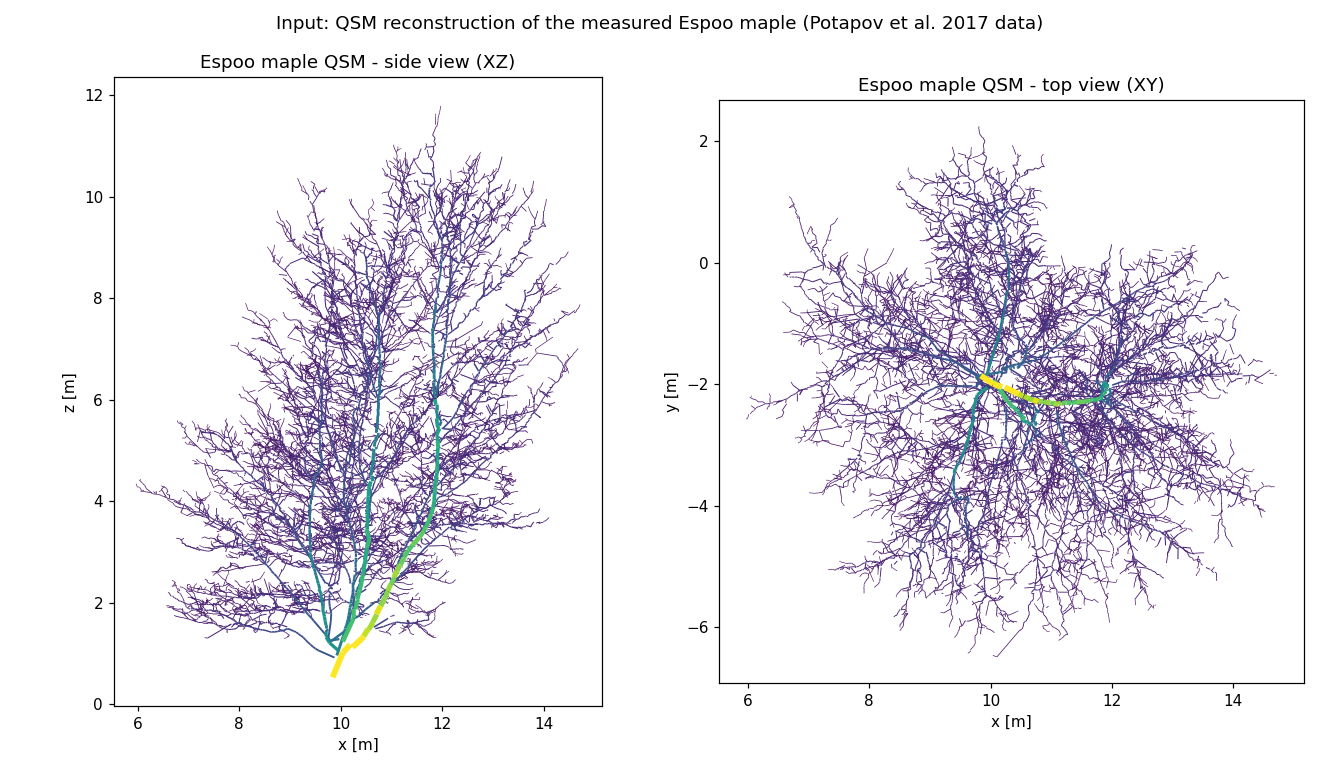

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

cyl = np.loadtxt("/content/work/cylinders.csv", delimiter=",")
# columns: radius, length, start(x,y,z), end(x,y,z)  [m]
r, sp, ep = cyl[:, 0], cyl[:, 2:5], cyl[:, 5:8]
print(f"cylinders: {len(cyl)}, radius range {r.min():.4f}..{r.max():.3f} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax, (i, j, ylabel, title) in zip(axes, [
        (0, 2, "z [m]", "side view (XZ)"), (0, 1, "y [m]", "top view (XY)")]):
    for k in np.argsort(r):  # draw thick cylinders last
        ax.plot([sp[k, i], ep[k, i]], [sp[k, j], ep[k, j]],
                lw=0.3 + 30 * r[k], color=plt.cm.viridis(r[k] / max(r.max(), 1e-9)),
                solid_capstyle="butt")
    ax.set_title(f"Espoo maple QSM - {title}")
    ax.set_xlabel("x [m]"); ax.set_ylabel(ylabel); ax.set_aspect("equal")
fig.suptitle("Input: QSM reconstruction of the measured Espoo maple (Potapov et al. 2017 data)")
fig.tight_layout()
fig.savefig("/content/work/tree_render.png", dpi=110, facecolor="white")
plt.close(fig)
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="/content/work/tree_render.png"))

## 6b. Structural feature distributions (S1, B2)

**Purpose:** visualize the empirical distributions that the distance DS compares: the
segment features of order-1 branches (**S1**: radius, length, gamma, zeta) and the
branch features of order 2 (**B2**: branching angle, azimuth, total length, initial
radius, distance along parent). These are the "data distributions U" the paper's
optimizer matches; here they document the actual measured input. Units: meters and
degrees, as defined in the author's feature tables.

(日本語) DS が比較する経験分布(S1 セグメント特徴量、B2 ブランチ特徴量)の
ヒストグラムを表示します。単位は表の定義どおり m と degree です。

S1 (order-1 segments) n = 1886  B2 (order-2 branches) n = 492


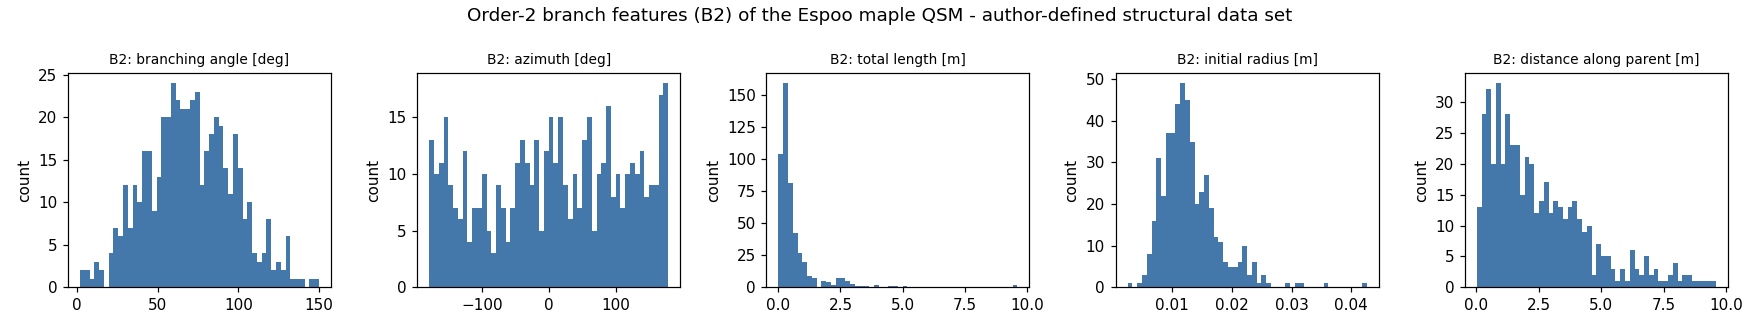

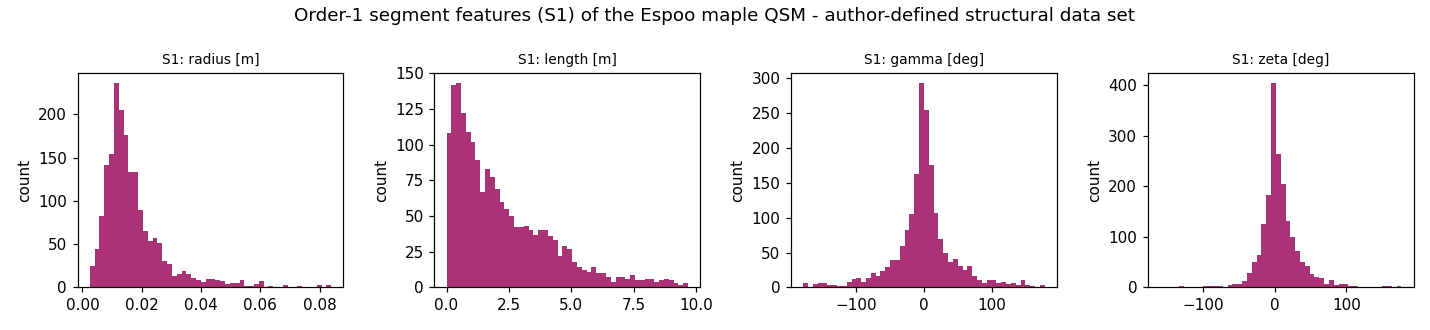

In [ ]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

S1 = np.loadtxt("/content/work/S1.csv", delimiter=",")
B2 = np.loadtxt("/content/work/B2.csv", delimiter=",")
assert S1.shape[1] == 4 and B2.shape[1] == 5, "unexpected feature count"
print("S1 (order-1 segments) n =", len(S1), " B2 (order-2 branches) n =", len(B2))

b_names = ["branching angle [deg]", "azimuth [deg]", "total length [m]",
           "initial radius [m]", "distance along parent [m]"]
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for k in range(5):
    axes[k].hist(B2[:, k], bins=50, color="#4477aa")
    axes[k].set_title(f"B2: {b_names[k]}", fontsize=9)
    axes[k].set_ylabel("count")
fig.suptitle("Order-2 branch features (B2) of the Espoo maple QSM - author-defined structural data set")
fig.tight_layout(); fig.savefig("/content/work/B2_hist.png", dpi=110, facecolor="white"); plt.close(fig)
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="/content/work/B2_hist.png"))

s_names = ["radius [m]", "length [m]", "gamma [deg]", "zeta [deg]"]
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for k in range(4):
    axes[k].hist(S1[:, k], bins=50, color="#aa3377")
    axes[k].set_title(f"S1: {s_names[k]}", fontsize=9)
    axes[k].set_ylabel("count")
fig.suptitle("Order-1 segment features (S1) of the Espoo maple QSM - author-defined structural data set")
fig.tight_layout(); fig.savefig("/content/work/S1_hist.png", dpi=110, facecolor="white"); plt.close(fig)
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="/content/work/S1_hist.png"))

## 7. Structural distance DS with the authors' code

**Purpose:** run the paper's distance measure — the *distribution tomography* structural
distance — with the authors' own `dt_distance` code: project both samples onto 1000
quasi-Monte-Carlo directions in R^N, compute the two-sample Kolmogorov–Smirnov statistic
per direction, and average (paper's "Distance measure" phase; N=4 for segment data, N=5
for branch data). The paper's published best-fit values (dh=0.05, dg=0.20, ...) are
QSM-vs-SSM comparisons.

**What we compute (honest labeling):** the SSM is unavailable here (needs MATLAB + the
LPFG simulator), so there is no model tree to compare against. As a framework
self-consistency check we compute DS between two **disjoint random halves** of the data
tree's own S1 and B2 samples (fixed seed 42, documented). **These values are not
published paper results** — they are the "distance of the data from itself", the noise
floor any future SSM comparison would have to beat.

(日本語) 論文の距離 DS(1000 方向の qMC 射影 + KS 統計量の平均)を著者コードで計算します。
SSM が使えないため、データ自身を半分に分割した自己整合性チェックを示します。
これは論文の結果値ではありません。

In [ ]:
import pathlib, subprocess

WORK = pathlib.Path("/content/work")
DRIVER = r'''
addpath(genpath('/content/bf'));
S1 = csvread('/content/work/S1.csv'); B2 = csvread('/content/work/B2.csv');
S1 = S1'; B2 = B2';   % dt_distance expects dim x n (each column one datapoint)
rand('seed', 42);     % fixed seed, documented in the notebook

p = randperm(columns(S1)); h = floor(columns(S1)/2);
A1 = S1(:, p(1:h)); A2 = S1(:, p(h+1:end));
[ds_sum, ds_max] = dt_distance(A1, A2, 1000, 1, 0);   % author code: KS statistic, 1000 directions

p = randperm(columns(B2)); h = floor(columns(B2)/2);
Ab1 = B2(:, p(1:h)); Ab2 = B2(:, p(h+1:end));
[db_sum, db_max] = dt_distance(Ab1, Ab2, 1000, 1, 0);

printf('S1 split-half DS: mean=%.4f max=%.4f (n1=%d, n2=%d, dim=%d)\n', ds_sum, ds_max, columns(A1), columns(A2), rows(S1));
printf('B2 split-half DS: mean=%.4f max=%.4f (n1=%d, n2=%d, dim=%d)\n', db_sum, db_max, columns(Ab1), columns(Ab2), rows(B2));
fid = fopen('/content/work/distance.csv', 'w');
fprintf(fid, 'dataset,DS_mean_1000dir_KS,DS_max,n1,n2,dim\n');
fprintf(fid, 'S1_half_vs_half,%.6f,%.6f,%d,%d,%d\n', ds_sum, ds_max, columns(A1), columns(A2), rows(S1));
fprintf(fid, 'B2_half_vs_half,%.6f,%.6f,%d,%d,%d\n', db_sum, db_max, columns(Ab1), columns(Ab2), rows(B2));
fclose(fid);
'''
(WORK / "run_distance.m").write_text(DRIVER.lstrip())
r = subprocess.run(["octave", "--quiet", "run_distance.m"], cwd=WORK, timeout=1800,
                   capture_output=True, text=True)
print(r.stdout[-4000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("octave run_distance failed")
print("run_distance done")

S1 split-half DS: mean=0.0321 max=0.0509 (n1=943, n2=943, dim=4)
B2 split-half DS: mean=0.0567 max=0.1057 (n1=246, n2=246, dim=5)

run_distance done


## 8. Classical clone-evaluation metrics: height, girth, crown spread

**Purpose:** compute the three coarse metrics the paper uses to evaluate generated
clones against the QSM ("Clone evaluation" phase), following the definitions in the
author's `tree_basic_metrics.m`: **height** = highest point above the trunk base;
**girth** = trunk diameter (2×radius) at 1.3 m along the trunk extension chain;
**crown spread** = 2× the mean over 1° azimuthal slices of the maximum radial distance
of branch endpoints. Because the metric helper is bound to the MATLAB classdef tree, it
is **adapted** here to the plain-struct tree with identical formulas (labeled ADAPTED).
For a single data tree these are descriptive values, not clone statistics.

(日本語) 論文のクローン評価指標(樹高・胸高直径・樹冠幅)を著者の定義どおり計算します。

In [ ]:
import pathlib, subprocess

WORK = pathlib.Path("/content/work")
METRICS = r'''
function [h, g, c] = bf_metrics_adapted(tr)
% ADAPTED from tree_basic_metrics.m (inuritdino/BayesForest @ 3f6c81e...) for a
% plain-struct tree; formulas identical to the author's height()/girth()/crown().
girth_height = 1.3;
h = max(max(tr.start_point(:,3)), max(tr.end_point(:,3)));
h = h - tr.start_point(1,3);
ii = 1; g = 0.0; found = false;
if ((abs(tr.start_point(ii,3)-tr.start_point(1,3)) <= girth_height) && ...
    (abs(tr.end_point(ii,3)-tr.start_point(1,3)) >= girth_height))
  g = 2 * tr.radius(ii); found = true;
end
while ~found && tr.extension(ii)
  ii = tr.extension(ii);
  if ((abs(tr.start_point(ii,3)-tr.start_point(1,3)) <= girth_height) && ...
      (abs(tr.end_point(ii,3)-tr.start_point(1,3)) >= girth_height))
    g = 2 * tr.radius(ii); found = true;
  end
end
if ~found
  printf('warning: no cylinder spanning 1.3 m found on the trunk extension chain\n');
end
dn = 1.0; deg = -180:dn:180; m = length(deg);
angles = (180/pi) * atan2(tr.end_point(:,2), tr.end_point(:,1));
center = [tr.start_point(1,1) tr.start_point(1,2)];
dists = sqrt((tr.end_point(:,1)-center(1)).^2 + (tr.end_point(:,2)-center(2)).^2);
spokes = [];
for jj = 2:m
  ii = find(angles < deg(jj) & angles > deg(jj-1));
  if isempty(ii), continue; end
  spokes(end+1) = max(dists(ii));  %#ok<SAGROW>
end
spokes = spokes(spokes ~= 0);
c = 2 * mean(spokes);
end
'''
DRIVER = r'''
addpath(genpath('/content/work')); addpath(genpath('/content/bf'));
% import_qsm_data saves the cylinder fields before building its tree object,
% so rebuild the same struct here (identical fields/formulas):
S = load('/content/work/tmp.mat');
tr = struct('radius',S.Rad,'length',S.Len,'start_point',S.Sta,'axis',S.Axe, ...
            'end_point',S.Sta + bsxfun(@times,S.Len,S.Axe), ...
            'parent',S.CPar,'extension',S.CExt);
[h, g, c] = bf_metrics_adapted(tr);
printf('height = %.2f m, girth(1.3 m) = %.3f m, crown spread = %.2f m\n', h, g, c);
fid = fopen('/content/work/metrics.csv', 'w');
fprintf(fid, 'metric,value_m\nheight,%.4f\ngirth_1p3m,%.4f\ncrown_spread,%.4f\n', h, g, c);
fclose(fid);
'''
(WORK / "bf_metrics_adapted.m").write_text(METRICS.lstrip())
(WORK / "run_metrics.m").write_text(DRIVER.lstrip())
r = subprocess.run(["octave", "--quiet", "run_metrics.m"], cwd=WORK, timeout=600,
                   capture_output=True, text=True)
print(r.stdout[-4000:])
if r.returncode != 0:
    print(r.stderr[-4000:])
    raise RuntimeError("octave run_metrics failed")
print("run_metrics done")

height = 11.25 m, girth(1.3 m) = 0.227 m, crown spread = 8.81 m

run_metrics done


## 9. Summary, limitations, provenance

**Executed here (CPU; Octave running the authors' pinned MATLAB code):** Espoo maple QSM
tables loaded and validated (row/column counts match the paper's ~3,078-branch /
~19,000-cylinder description); structural data sets S_w/B_w extracted with the author's
`gen_scatter2`; input tree rendered; structural distance DS computed with the author's
`dt_distance` (1000 qMC directions, KS statistic) on split halves of S1/B2; classical
metrics (height/girth/crown spread) computed per the author's definitions. All numbers
shown are produced by the cells above from the actual downloaded data.

**Not executed (documented blocker):** clone generation and GA optimization. The SSM is
the self-organizing tree model simulated through **LPFG** (VLAB/L-studio; the authors
used a 64-bit Mac OS X binary), driven by MATLAB R2015b, with reported run times up to
several days. This cannot run in Colab, so the best-fit SSM parameters stored in
`morpho-clones.zip` were not re-simulated and no clone trees were generated. The
split-half DS values are framework self-consistency checks, **not** paper results.

**Provenance:** code = `inuritdino/BayesForest` @
`3f6c81e9b135719b9a7e479dc5d2c07b392cd9de` (MIT, see repo COPYING); data = Espoo QSM
tables linked from the authors' wiki *Data-samples* page + `morpho-clones.zip` from the
TUT Bayes-Forest page (SHA-256 printed at download). Adaptations are documented in
sections 4 and 8.

**References:** Potapov et al., bioRxiv 10.1101/108530 (2017); *Bayes Forest*,
GigaScience 6(10), 2017; Raumonen et al., Remote Sensing 5:491 (2013) (QSM method).

(日本語) 以上、Espoo マープル QSM の読み込み・構造データセット抽出・DS 距離計算・
基本指標計算を著者コード(CPU/Octave)で実行しました。クローン生成(SSM+LPFG+GA)は
Colab では実行できないため未実施であり、代わりの値は捏造していません。